# Snore Detection — Extreme Noise Training Regimes (Where Does Accuracy Drop?)

This notebook keeps your pipeline (ESC‑50 noise augmentation → **YAMNet** embeddings → small **MLP**) and **pushes noise much harder** to see when performance breaks.

We train multiple models, each with a different **training SNR range (dB)**:

- **Baseline-Med:** 8–14 dB (reference point)
- **Heavy:** 0–7 dB
- **Very-Heavy:** 0–5 dB
- **Severe:** −5–0 dB *(noise slightly stronger than signal)*
- **Extreme:** −10 to −6 dB *(noise much stronger than signal)*

Each model is evaluated on:
- **Clean test** (no added noise), and
- **Stressed noisy test** with a **fixed 0–10 dB SNR** at inference for fair comparison.

> Tip: Lower/negative SNR = harder. Expect clean accuracy to fall gradually and noisy accuracy to improve up to a point, then collapse when training is too adversarial.


In [ ]:
# Install & mount
!pip install -q librosa soundfile noisereduce tensorflow_hub tqdm scikit-learn matplotlib joblib

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Paths & data (adjust if your structure differs)
import os

SNORE_ROOT = "/content/drive/MyDrive/snore_data"
NOISE_ROOT = "/content/drive/MyDrive/noise_data"
os.makedirs(SNORE_ROOT, exist_ok=True)
os.makedirs(NOISE_ROOT, exist_ok=True)

# Download datasets if missing (Snoring + ESC-50)
!pip install -q kaggle
from google.colab import files
try:
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        import shutil, os
        os.makedirs('/root/.kaggle', exist_ok=True)
        shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
        !chmod 600 /root/.kaggle/kaggle.json
except Exception as e:
    pass

snore_target = os.path.join(SNORE_ROOT, "Snoring Dataset")
if not os.path.isdir(snore_target):
    print("Downloading snoring dataset...")
    !kaggle datasets download tareqkhanemu/snoring -p "$SNORE_ROOT" --unzip
else:
    print("Snoring dataset already present.")

esc50_target = os.path.join(NOISE_ROOT, "audio", "audio")
if not os.path.isdir(esc50_target):
    print("Downloading ESC-50 concatenated WAVs (noise)...")
    !kaggle datasets download mmoreaux/environmental-sound-classification-50 -p "$NOISE_ROOT" --unzip
else:
    print("ESC-50 already present.")

SNORE_PATH      = "/content/drive/MyDrive/snore_data/Snoring Dataset/1"
NON_SNORE_PATH  = "/content/drive/MyDrive/snore_data/Snoring Dataset/0"
NOISE_PATH      = "/content/drive/MyDrive/noise_data/audio/audio"

print("Sanity counts:")
print("Snore files:", len([f for f in os.listdir(SNORE_PATH) if f.lower().endswith('.wav')]))
print("Non-snore files:", len([f for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith('.wav')]))
print("Noise wavs:", len([f for f in os.listdir(NOISE_PATH) if f.lower().endswith('.wav')]))

assert os.path.isdir(SNORE_PATH), "Missing snore folder"
assert os.path.isdir(NON_SNORE_PATH), "Missing non-snore folder"
assert os.path.isdir(NOISE_PATH), "Missing ESC-50 noise folder"


Saving kaggle.json to kaggle.json
Snoring dataset already present.
ESC-50 already present.
Sanity counts:
Snore files: 500
Non-snore files: 500
Noise wavs: 2000


In [ ]:
# YAMNet + audio utils
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
import librosa, random, glob
from tqdm import tqdm

yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")

noise_files = [os.path.join(NOISE_PATH, f) for f in os.listdir(NOISE_PATH) if f.lower().endswith(".wav")]
assert len(noise_files) > 0, "No noise wavs found — check NOISE_PATH."

def match_noise_to_signal(noise, sig_len):
    if len(noise) < sig_len:
        reps = int(np.ceil(sig_len / len(noise)))
        noise = np.tile(noise, reps)
    if len(noise) > sig_len:
        start = np.random.randint(0, len(noise) - sig_len + 1)
        noise = noise[start:start+sig_len]
    return noise

def mix_audio_with_noise(audio: np.ndarray, noise: np.ndarray, snr_db: float = 10.0) -> np.ndarray:
    noise = match_noise_to_signal(noise, len(audio))
    eps = 1e-9
    rms_s = np.sqrt(np.mean(audio**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return audio + k*noise

def load_with_optional_noise(file_path: str, add_noise: bool = False, sr: int = 16000, target_sec: float = 3.0,
                             snr_low: float = 5.0, snr_high: float = 20.0) -> np.ndarray:
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_len = int(sr*target_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    if add_noise and noise_files:
        n, _ = librosa.load(random.choice(noise_files), sr=sr, mono=True)
        snr = random.uniform(snr_low, snr_high)
        y = mix_audio_with_noise(y, n, snr_db=snr)
    return y.astype(np.float32)

def extract_yamnet_stats_from_waveform(y: np.ndarray) -> np.ndarray:
    y_tf = tf.convert_to_tensor(y, dtype=tf.float32)
    _, embeddings, _ = yamnet_model(y_tf)        # (T,1024)
    E = embeddings.numpy()
    return np.concatenate([E.mean(axis=0), E.std(axis=0)], axis=0)  # 2048-D


In [ ]:
# Build splits
from sklearn.model_selection import train_test_split

snore_files = [os.path.join(SNORE_PATH, f) for f in os.listdir(SNORE_PATH) if f.lower().endswith(".wav")]
non_files   = [os.path.join(NON_SNORE_PATH, f) for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith(".wav")]

X_paths = snore_files + non_files
y_all   = np.array([1]*len(snore_files) + [0]*len(non_files))

X_tr_paths, X_te_paths, y_tr, y_te = train_test_split(
    X_paths, y_all, test_size=0.2, random_state=42, stratify=y_all
)

len(snore_files), len(non_files), len(X_tr_paths), len(X_te_paths)


(500, 500, 800, 200)

In [ ]:
# Feature extraction with configurable SNR range
def features_from_paths(paths, add_noise=False, snr_low=5.0, snr_high=20.0):
    feats = []
    for p in tqdm(paths, desc=f"Extract (noise={add_noise}, SNR=[{snr_low},{snr_high}] dB)"):
        y = load_with_optional_noise(p, add_noise=add_noise, sr=16000, target_sec=3.0,
                                     snr_low=snr_low, snr_high=snr_high)
        feats.append(extract_yamnet_stats_from_waveform(y))
    return np.stack(feats)


In [ ]:
# Train & evaluate across extreme regimes
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd, json, time, joblib

noise_regimes = {
    "Baseline-Med": (8.0, 14.0),
    "Heavy":        (0.0, 7.0),
    "Very-Heavy":   (0.0, 5.0),
    "Severe":       (-5.0, 0.0),
    "Extreme":      (-10.0, -6.0),
}

EVAL_NOISY_RANGE = (0.0, 10.0)  # stressed evaluation for all models

results = {}
histories = {}

for label, (snr_lo, snr_hi) in noise_regimes.items():
    print(f"\n=== Training regime: {label} (SNR {snr_lo} to {snr_hi} dB) ===")
    X_tr = features_from_paths(X_tr_paths, add_noise=True, snr_low=snr_lo, snr_high=snr_hi)
    X_te_clean = features_from_paths(X_te_paths, add_noise=False)
    X_te_noisy = features_from_paths(X_te_paths, add_noise=True, snr_low=EVAL_NOISY_RANGE[0], snr_high=EVAL_NOISY_RANGE[1])

    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_te_clean_s = scaler.transform(X_te_clean)
    X_te_noisy_s = scaler.transform(X_te_noisy)

    mlp = models.Sequential([
        layers.Input((X_tr_s.shape[1],)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.30),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.20),
        layers.Dense(1, activation='sigmoid')
    ])
    mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss='binary_crossentropy', metrics=['accuracy'])

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5),
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]

    t0 = time.time()
    hist = mlp.fit(X_tr_s, y_tr, epochs=40, batch_size=32, validation_split=0.15, callbacks=callbacks, verbose=1)
    t1 = time.time()

    histories[label] = hist.history

    # Evaluate helper
    def eval_split(Xs, yt):
        probs = mlp.predict(Xs).ravel()
        preds = (probs >= 0.5).astype(int)
        return {
            "accuracy": float(accuracy_score(yt, preds)),
            "precision": float(precision_score(yt, preds)),
            "recall": float(recall_score(yt, preds)),
            "f1": float(f1_score(yt, preds)),
            "roc_auc": float(roc_auc_score(yt, probs)),
        }

    metrics_clean = eval_split(X_te_clean_s, y_te)
    metrics_noisy = eval_split(X_te_noisy_s, y_te)

    results[label] = {
        "train_snr_db": [snr_lo, snr_hi],
        "fit_seconds": round(t1 - t0, 2),
        "clean": metrics_clean,
        "noisy_eval_0_10db": metrics_noisy,
    }

    # Save artifacts per regime
    out_dir = f"/content/drive/MyDrive/snore_models/extreme/{label}_snr_{int(snr_lo)}_{int(snr_hi)}"
    os.makedirs(out_dir, exist_ok=True)
    mlp.save(os.path.join(out_dir, "mlp.h5"))
    joblib.dump(scaler, os.path.join(out_dir, "scaler.joblib"))
    joblib.dump({"history": hist.history, "results": results[label]}, os.path.join(out_dir, "training_meta.joblib"))

print("\nSummary:")
print(json.dumps(results, indent=2))



=== Training regime: Baseline-Med (SNR 8.0 to 14.0 dB) ===


Extract (noise=True, SNR=[0.0,10.0] dB): 100%|██████████| 200/200 [00:39<00:00,  5.06it/s]


Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5829 - loss: 1.0842 - val_accuracy: 0.7083 - val_loss: 0.5080 - learning_rate: 0.0010
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7117 - loss: 0.8100 - val_accuracy: 0.8000 - val_loss: 0.7605 - learning_rate: 0.0010
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8020 - loss: 0.6559 - val_accuracy: 0.8333 - val_loss: 0.3759 - learning_rate: 0.0010
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8176 - loss: 0.5634 - val_accuracy: 0.8583 - val_loss: 0.3242 - learning_rate: 0.0010
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8435 - loss: 0.5157 - val_accuracy: 0.8667 - val_loss: 0.3416 - learning_rate: 0.0010
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8917 - loss: 0.2895 - val_accuracy: 0.8500 - val_loss: 0.3335 - learning_rate: 0.0010
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8726 - loss: 0.3582 - val_acc


=== Training regime: Heavy (SNR 0.0 to 7.0 dB) ===


Extract (noise=True, SNR=[0.0,10.0] dB): 100%|██████████| 200/200 [00:28<00:00,  6.93it/s]


...

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4932 - loss: 1.2428 - val_accuracy: 0.5083 - val_loss: 1.2312 - learning_rate: 0.0010
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5818 - loss: 1.1196 - val_accuracy: 0.6083 - val_loss: 1.3016 - learning_rate: 0.0010
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6409 - loss: 0.9816 - val_accuracy: 0.6500 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6845 - loss: 0.9189 - val_accuracy: 0.6667 - val_loss: 0.6634 - learning_rate: 0.0010
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6789 - loss: 0.8186 - val_accuracy: 0.6917 - val_loss: 0.6196 - learning_rate: 0.0010
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7296 - loss: 0.6795 - val_accuracy: 0.7167 - val_loss: 0.5624 - learning_rate: 0.0010
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7662 - loss: 0.5971 - val_acc


=== Training regime: Extreme (SNR -10.0 to -6.0 dB) ===


Extract (noise=True, SNR=[0.0,10.0] dB): 100%|██████████| 200/200 [00:16<00:00, 11.83it/s]


Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5309 - loss: 1.2304 - val_accuracy: 0.5417 - val_loss: 0.6615 - learning_rate: 0.0010
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5772 - loss: 1.0916 - val_accuracy: 0.5917 - val_loss: 1.0501 - learning_rate: 0.0010
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6099 - loss: 1.1114 - val_accuracy: 0.6000 - val_loss: 0.6639 - learning_rate: 0.0010
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6634 - loss: 0.7246 - val_accuracy: 0.6250 - val_loss: 0.6314 - learning_rate: 5.0000e-04
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6883 - loss: 0.6435 - val_accuracy: 0.5667 - val_loss: 0.7216 - learning_rate: 5.0000e-04
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7079 - loss: 0.6651 - val_accuracy: 0.6833 - val_loss: 0.6227 - learning_rate: 5.0000e-04
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7237 - loss: 0.57


Summary:
{
  "Baseline-Med": {
    "train_snr_db": [
      8.0,
      14.0
    ],
    "fit_seconds": 11.43,
    "clean": {
      "accuracy": 0.975,
      "precision": 0.9702970297029703,
      "recall": 0.98,
      "f1": 0.9751243781094527,
      "roc_auc": 0.9985
    },
    "noisy_eval_0_10db": {
      "accuracy": 0.855,
      "precision": 0.8380952380952381,
      "recall": 0.88,
      "f1": 0.8585365853658536,
      "roc_auc": 0.9126
    }
  },
  "Heavy": {
    "train_snr_db": [
      0.0,
      7.0
    ],
    "fit_seconds": 12.39,
    "clean": {
      "accuracy": 0.93,
      "precision": 0.9215686274509803,
      "recall": 0.94,
      "f1": 0.9306930693069307,
      "roc_auc": 0.9827
    },
    "noisy_eval_0_10db": {
      "accuracy": 0.845,
      "precision": 0.8349514563106796,
      "recall": 0.86,
      "f1": 0.8472906403940886,
      "roc_auc": 0.9318
    }
  },
  "Very-Heavy": {
    "train_snr_db": [
      0.0,
      5.0
    ],
    "fit_seconds": 12.28,
    "clean": {
      

,accuracy,precision,recall,f1,roc_auc,Train SNR (dB)
Regime,,,,,,
Baseline-Med,0.975,0.970297,0.98,0.975124,0.9985,8.0–14.0
Extreme,0.940,0.907407,0.98,0.942308,0.9889,-10.0–-6.0
Heavy,0.930,0.921569,0.94,0.930693,0.9827,0.0–7.0
Severe,0.965,1.000000,0.93,0.963731,0.9932,-5.0–0.0
Very-Heavy,0.920,0.862069,1.00,0.925926,0.9944,0.0–5.0


,accuracy,precision,recall,f1,roc_auc,Train SNR (dB)
Regime,,,,,,
Baseline-Med,0.855,0.838095,0.88,0.858537,0.9126,8.0–14.0
Extreme,0.790,0.784314,0.80,0.792079,0.8532,-10.0–-6.0
Heavy,0.845,0.834951,0.86,0.847291,0.9318,0.0–7.0
Severe,0.880,0.858491,0.91,0.883495,0.9130,-5.0–0.0
Very-Heavy,0.845,0.800000,0.92,0.855814,0.9335,0.0–5.0


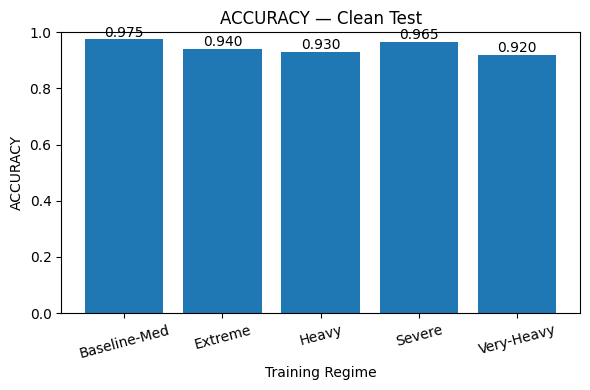

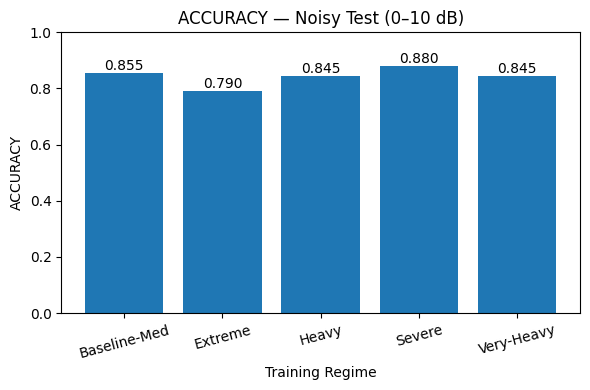

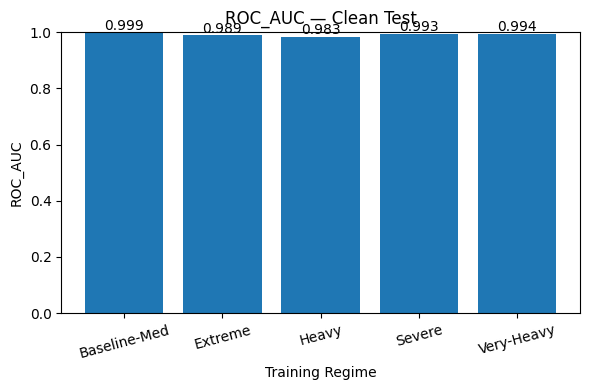

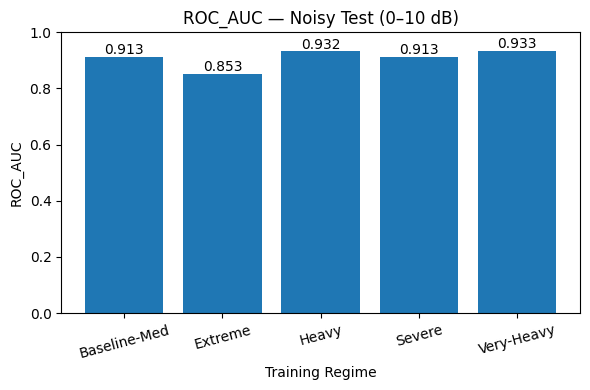

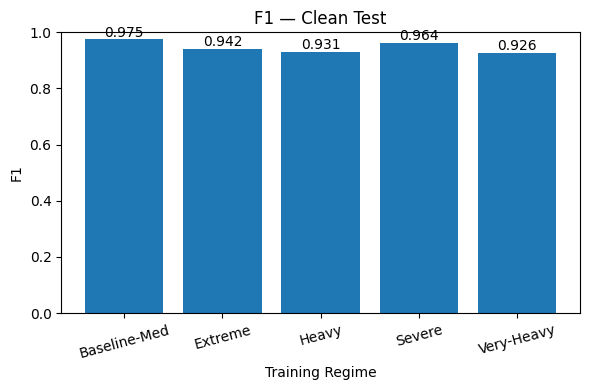

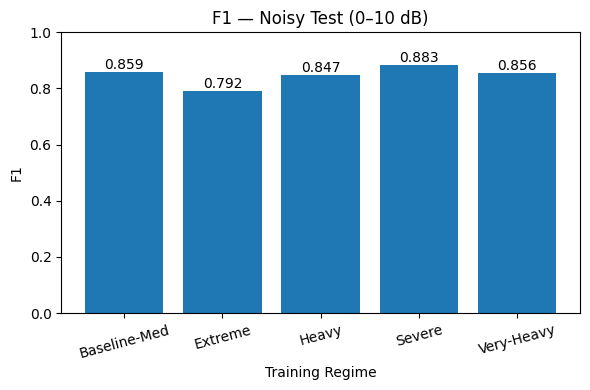

In [ ]:
# Compare regimes: tables + Matplotlib charts
import pandas as pd
import matplotlib.pyplot as plt

rows_clean, rows_noisy = [], []
for label, data in results.items():
    c = data["clean"].copy()
    c.update({"Regime": label, "Train SNR (dB)": f"{data['train_snr_db'][0]}–{data['train_snr_db'][1]}"})
    rows_clean.append(c)

    n = data["noisy_eval_0_10db"].copy()
    n.update({"Regime": label, "Train SNR (dB)": f"{data['train_snr_db'][0]}–{data['train_snr_db'][1]}"})
    rows_noisy.append(n)

df_clean = pd.DataFrame(rows_clean).set_index("Regime").sort_index()
df_noisy = pd.DataFrame(rows_noisy).set_index("Regime").sort_index()

display(df_clean)
display(df_noisy)

def plot_metric(df, metric, title):
    plt.figure(figsize=(6,4))
    ordered = df.sort_index()
    plt.bar(ordered.index, ordered[metric].values)
    plt.title(title)
    plt.xlabel("Training Regime")
    plt.ylabel(metric.upper())
    plt.ylim(0,1)
    for i, v in enumerate(ordered[metric].values):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

for m in ["accuracy", "roc_auc", "f1"]:
    plot_metric(df_clean, m, f"{m.upper()} — Clean Test")
    plot_metric(df_noisy, m, f"{m.upper()} — Noisy Test (0–10 dB)")

## Notes & Tweaks

- **Negative SNR** means the *noise RMS is higher* than the signal RMS during training — very adversarial.
- If training collapses (e.g., unstable validation, poor clean accuracy), try:
  - Narrowing the negative SNR band (e.g., −4 to 0 dB)
  - Fewer epochs, stronger regularization (increase dropout), or smaller layers
  - Mixing regimes (curriculum): start Heavy (0–7), then fine‑tune at Severe (−5–0)
- The evaluation noisy range is fixed at **0–10 dB** to keep comparisons fair across regimes. Change `EVAL_NOISY_RANGE` to match your target environment.
